In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the cc calls data
df = pd.read_csv('../../data/cc_calls.csv')

# Print basic info
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 Rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes)

Dataset Shape: (32882, 33)

First 5 Rows:
     Contact_ID   Call_Date  Direction cc_care_package  \
0  6.255130e+11  08-05-2025  OUT_BOUND        Standard   
1  5.910870e+11  25-11-2024  OUT_BOUND        Standard   
2  5.650910e+11  23-10-2024   IN_BOUND        Standard   
3  5.939750e+11  13-01-2025   IN_BOUND         Premier   
4  6.222820e+11  19-03-2025   IN_BOUND        Standard   

  cc_care_package_discussed cc_urgency_getting_on_site cc_external_consultant  \
0                       Yes                         No                     No   
1                       Yes                         No                     No   
2                       Yes                         No                     No   
3                       Yes                         No                     No   
4                       Yes                         No                     No   

  cc_agent_cross_sell_attempt cc_customer_issues_concerns  \
0                          No                         Yes   


In [7]:
# Column Inventory: all columns with their dtypes and null counts
column_info = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2)
})

# Flag numeric columns stored as object
numeric_as_object = []
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            pd.to_numeric(df[col].dropna())
            numeric_as_object.append(col)
        except:
            pass

print("COLUMN INVENTORY:")
print(column_info.to_string(index=False))

if numeric_as_object:
    print(f" NUMERIC COLUMNS STORED AS OBJECT: {numeric_as_object}")

COLUMN INVENTORY:
                                  Column Data Type  Null Count  Null %
                              Contact_ID   float64           0    0.00
                               Call_Date       str           0    0.00
                               Direction       str           0    0.00
                         cc_care_package       str         138    0.42
               cc_care_package_discussed       str         138    0.42
              cc_urgency_getting_on_site       str         138    0.42
                  cc_external_consultant       str         138    0.42
             cc_agent_cross_sell_attempt       str         138    0.42
             cc_customer_issues_concerns       str         138    0.42
cc_business_struggles_financial_hardship       str         138    0.42
                    cc_call_initiated_by       str         138    0.42
             cc_questionnaire_completion       str          32    0.10
                     cc_chasing_response       str         

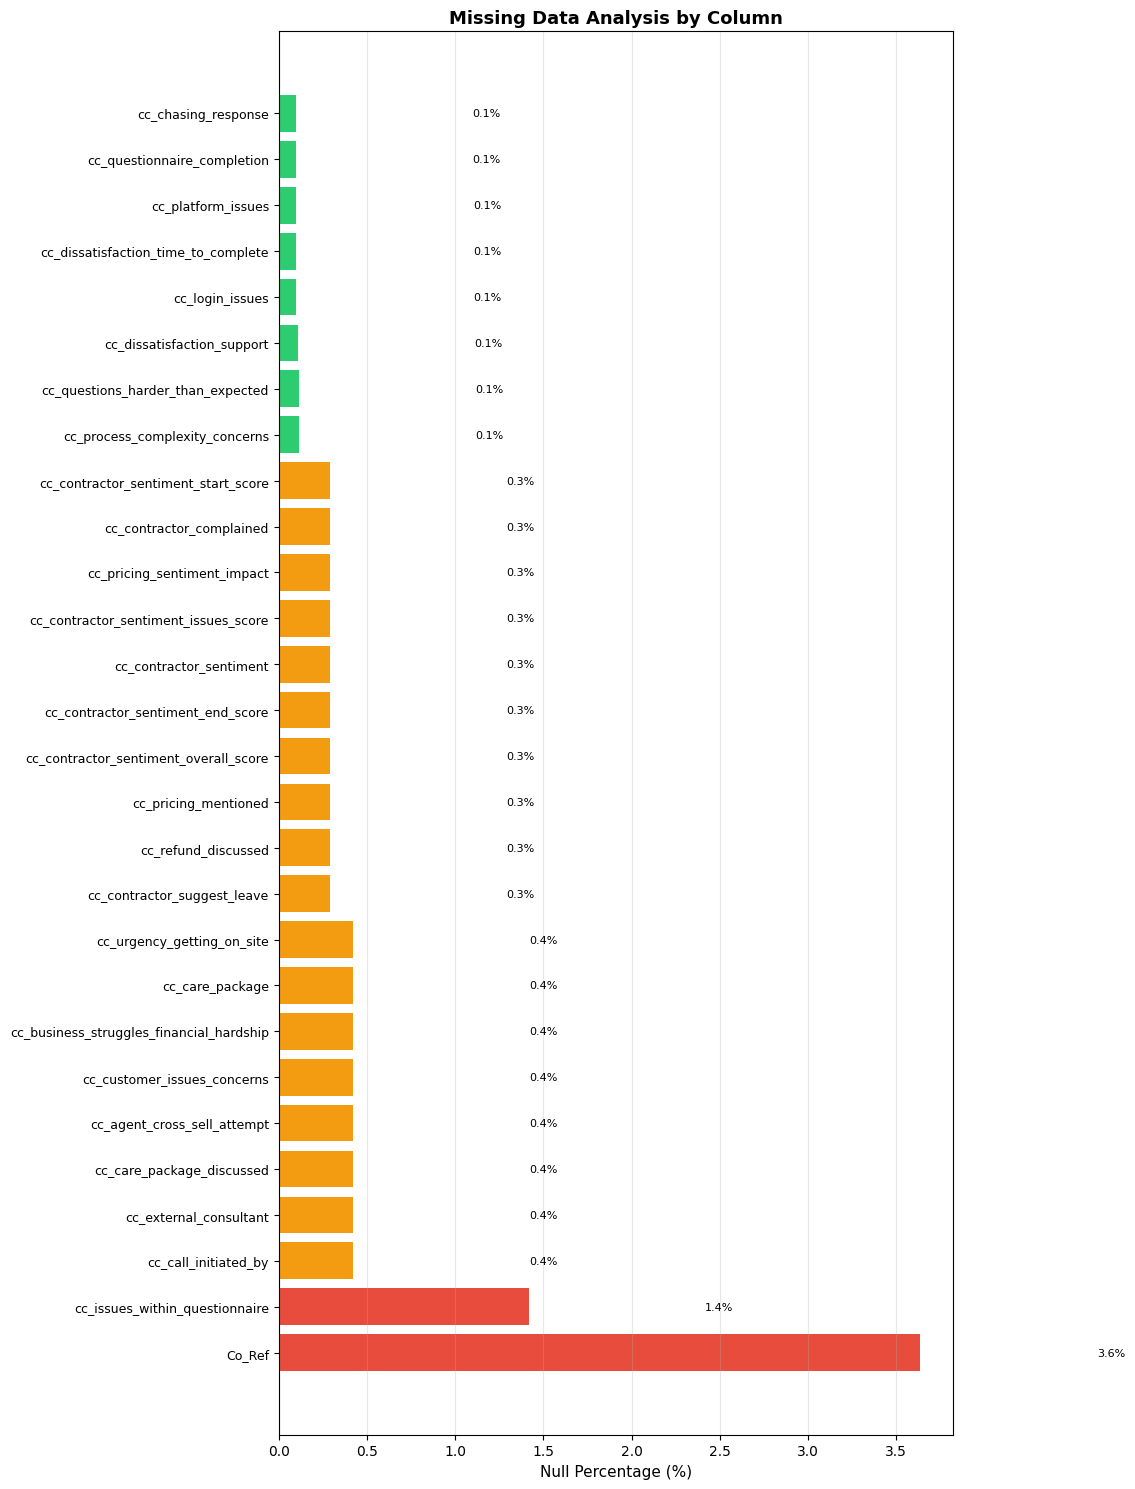


=== NULL ANALYSIS ===
                                  Column  Null Count  Null %
                                  Co_Ref        1196    3.64
          cc_issues_within_questionnaire         466    1.42
                    cc_call_initiated_by         138    0.42
                  cc_external_consultant         138    0.42
               cc_care_package_discussed         138    0.42
             cc_agent_cross_sell_attempt         138    0.42
             cc_customer_issues_concerns         138    0.42
cc_business_struggles_financial_hardship         138    0.42
                         cc_care_package         138    0.42
              cc_urgency_getting_on_site         138    0.42
             cc_contractor_suggest_leave          95    0.29
                     cc_refund_discussed          95    0.29
                    cc_pricing_mentioned          95    0.29
   cc_contractor_sentiment_overall_score          95    0.29
       cc_contractor_sentiment_end_score          95    0.29
 

In [13]:
null_counts = df.isnull().sum().sort_values(ascending=False)
null_pct = (null_counts / len(df) * 100)
null_pct_plt = null_pct[null_pct > 0].sort_values(ascending=False)

# Define colors based on threshold
colors = []
for pct in null_pct_plt:
    if pct > 1:
        colors.append('#e74c3c')  # red
    elif pct >= 0.25 and pct <= 1:
        colors.append('#f39c12')  # orange
    else:
        colors.append('#2ecc71')  # green

fig, ax = plt.subplots(figsize=(12, len(null_pct_plt) // 2 + 1))
ax.barh(range(len(null_pct_plt)), null_pct_plt.values, color=colors)
ax.set_yticks(range(len(null_pct_plt)))
ax.set_yticklabels(null_pct_plt.index, fontsize=9)
ax.set_xlabel('Null Percentage (%)', fontsize=11)
ax.set_title('Missing Data Analysis by Column', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add percentage labels
for i, pct in enumerate(null_pct_plt.values):
    ax.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\n=== NULL ANALYSIS ===")
null_df = pd.DataFrame({
    'Column': null_pct.index,
    'Null Count': null_counts.values,
    'Null %': null_pct.values.round(2)
})
print(null_df.to_string(index=False))

print("\n=== KEY OBSERVATIONS ===")
print("Expected High Nulls (First-Year Customers Logic):")
for col in ['Connection_Net', 'Last_Total_Net_Paid', 'Last_Band', 'Last_Connections', 'Last_Renewal']:
    if col in df.columns:
        pct = null_pct.get(col, 0)
        print(f"  {col}: {pct:.1f}%")

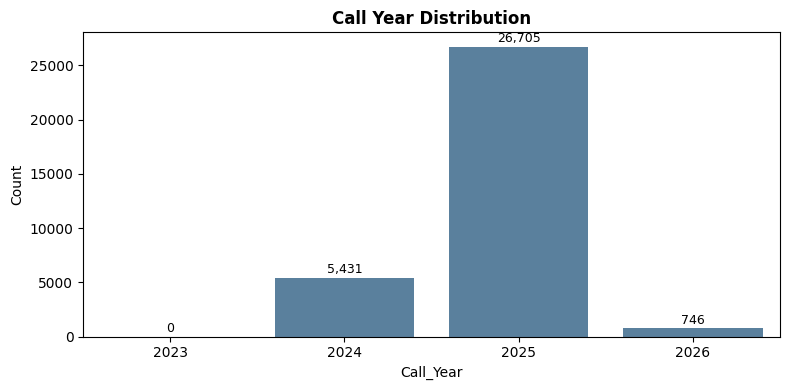

Call Year value counts (including explicit 2023=0 check):
2023: 0
2024: 5,431
2025: 26,705
2026: 746

Confirmations:
- 2023 rows: 0
- 2024 rows: 5,431
- 2025 rows: 26,705
- 2026 rows: 746
- 2024 row share in this file: 16.5% (5,431/32,882 rows)
- 2024 customer coverage in this file: 18.3% (91/496 customers)

Finding:
- This file starts from 2024 (no 2023 records present).
- 2024 coverage appears sparse, but 10.8% cannot be confirmed from this file alone.


In [15]:
# Call Year Distribution
year_counts = pd.to_numeric(df['Call_Year'], errors='coerce').dropna().astype(int).value_counts().sort_index()
year_counts_full = year_counts.reindex([2023, 2024, 2025, 2026], fill_value=0)

# Visualisation: bar chart of Call_Year value counts
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=year_counts_full.index, y=year_counts_full.values, color='#4f81a8')
ax.set_title('Call Year Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Call_Year')
ax.set_ylabel('Count')

# Label bars with counts
for i, v in enumerate(year_counts_full.values):
    ax.text(i, v + max(year_counts_full.values) * 0.005, f"{v:,}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Call Year value counts (including explicit 2023=0 check):')
for year, count in year_counts_full.items():
    print(f"{year}: {count:,}")

# Coverage checks
total_rows = len(df)
rows_2024 = int(year_counts_full.loc[2024])
row_share_2024 = (rows_2024 / total_rows) * 100

total_customers = df['Contact_ID'].nunique()
customers_2024 = df.loc[pd.to_numeric(df['Call_Year'], errors='coerce') == 2024, 'Contact_ID'].nunique()
coverage_2024 = (customers_2024 / total_customers) * 100

print('\nConfirmations:')
print(f"- 2023 rows: {year_counts_full.loc[2023]:,}")
print(f"- 2024 rows: {year_counts_full.loc[2024]:,}")
print(f"- 2025 rows: {year_counts_full.loc[2025]:,}")
print(f"- 2026 rows: {year_counts_full.loc[2026]:,}")
print(f"- 2024 row share in this file: {row_share_2024:.1f}% ({rows_2024:,}/{total_rows:,} rows)")
print(f"- 2024 customer coverage in this file: {coverage_2024:.1f}% ({customers_2024:,}/{total_customers:,} customers)")

print('\nFinding:')
print('- This file starts from 2024 (no 2023 records present).')
print('- 2024 coverage appears sparse, but 10.8% cannot be confirmed from this file alone.')

C:\Users\VaddiSriVenkataBhara\AppData\Local\Temp\ipykernel_2224\2665404721.py:2: DtypeWarning: Columns (0: Proforma_Auto_Renewal, 1: Proforma_World_Pay_Token, 2: Current_Anchor_List, 3: Last_Renewal, 4: Last_Band) have mixed types. Specify dtype option on import or set low_memory=False.
  billings_df = pd.read_csv('../../data/billings.csv')


=== CUSTOMER COVERAGE ===
Unique Co_Ref values with at least one cc call: 14,988
% of all billing customers who ever called customer care: 31.3% (14,988/47,826)
Finding: Most customers have zero cc calls, which can be a useful signal (no news = good news).


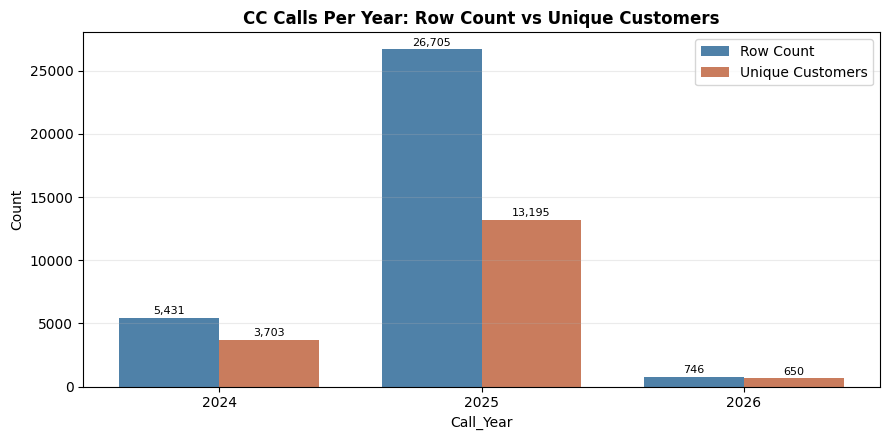

In [16]:
# Customer Coverage
billings_df = pd.read_csv('../../data/billings.csv')

# Use Co_Ref as the customer identifier for this analysis
cc_customers = (
    df['Co_Ref']
    .dropna()
    .astype(str)
    .str.strip()
    .replace('', np.nan)
    .dropna()
    .unique()
    )
billing_customers = (
    billings_df['Co_Ref']
    .dropna()
    .astype(str)
    .str.strip()
    .replace('', np.nan)
    .dropna()
    .unique()
    )

unique_cc_customers = len(cc_customers)
total_billing_customers = len(billing_customers)
pct_called_cc = (unique_cc_customers / total_billing_customers) * 100

print('=== CUSTOMER COVERAGE ===')
print(f"Unique Co_Ref values with at least one cc call: {unique_cc_customers:,}")
print(f"% of all billing customers who ever called customer care: {pct_called_cc:.1f}% ({unique_cc_customers:,}/{total_billing_customers:,})")
print('Finding: Most customers have zero cc calls, which can be a useful signal (no news = good news).')

# Visualisation: calls per year showing unique customer count vs row count
year_df = df.copy()
year_df['Call_Year_Num'] = pd.to_numeric(year_df['Call_Year'], errors='coerce').astype('Int64')

year_summary = (
    year_df.dropna(subset=['Call_Year_Num'])
    .groupby('Call_Year_Num')
    .agg(
        row_count=('Co_Ref', 'size'),
        unique_customer_count=('Co_Ref', lambda s: s.dropna().astype(str).str.strip().replace('', np.nan).dropna().nunique())
    )
    .reset_index()
    .sort_values('Call_Year_Num')
)

x = np.arange(len(year_summary))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))
bars_rows = ax.bar(x - width / 2, year_summary['row_count'], width, label='Row Count', color='#4f81a8')
bars_unique = ax.bar(x + width / 2, year_summary['unique_customer_count'], width, label='Unique Customers', color='#c97c5d')

ax.set_title('CC Calls Per Year: Row Count vs Unique Customers', fontsize=12, fontweight='bold')
ax.set_xlabel('Call_Year')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(year_summary['Call_Year_Num'].astype(int))
ax.legend()
ax.grid(axis='y', alpha=0.25)

for bars in [bars_rows, bars_unique]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + max(year_summary['row_count']) * 0.005, f"{int(h):,}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

=== CALLS PER CUSTOMER ===
Customers with at least one cc call: 14,988
Typical customer calls (median): 2
Average calls per customer: 2.11
90th percentile calls: 4

At-risk frequency buckets:
- Customers with 5+ calls: 1,105
- Customers with 10+ calls: 47
- Customers with 15+ calls: 7


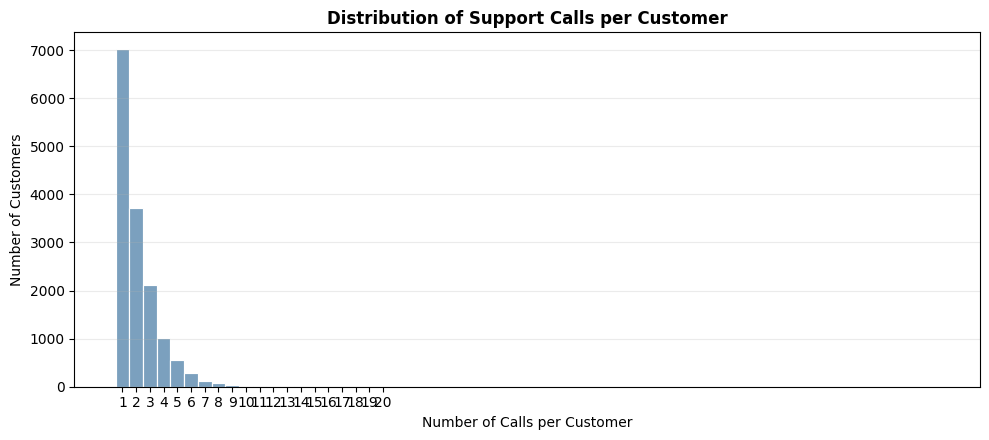


Yearly calls-per-customer summary:
                 count      mean  median  75%   max
Call_Year_Num                                      
2024            3703.0  1.453686     1.0  2.0  10.0
2025           13195.0  1.941417     1.0  2.0  51.0
2026             650.0  1.055385     1.0  1.0   3.0


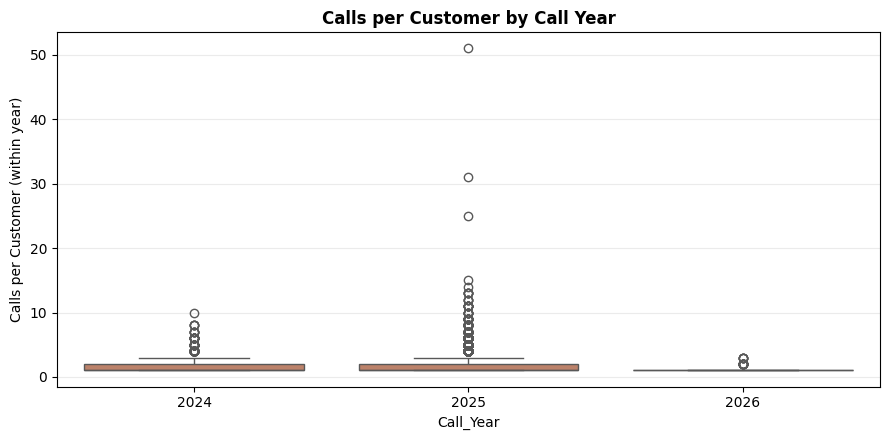

In [17]:
# Calls per Customer
customer_call_counts = (
    df['Co_Ref']
    .dropna()
    .astype(str)
    .str.strip()
    .replace('', np.nan)
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

print('=== CALLS PER CUSTOMER ===')
print(f"Customers with at least one cc call: {customer_call_counts.shape[0]:,}")
print(f"Typical customer calls (median): {customer_call_counts.median():.0f}")
print(f"Average calls per customer: {customer_call_counts.mean():.2f}")
print(f"90th percentile calls: {customer_call_counts.quantile(0.90):.0f}")

risk_5 = int((customer_call_counts >= 5).sum())
risk_10 = int((customer_call_counts >= 10).sum())
risk_15 = int((customer_call_counts >= 15).sum())

print('\nAt-risk frequency buckets:')
print(f"- Customers with 5+ calls: {risk_5:,}")
print(f"- Customers with 10+ calls: {risk_10:,}")
print(f"- Customers with 15+ calls: {risk_15:,}")

# Visualisation 1: histogram of calls per customer
plt.figure(figsize=(10, 4.5))
max_calls = int(customer_call_counts.max())
bins = np.arange(1, max_calls + 2) - 0.5
sns.histplot(customer_call_counts, bins=bins, color='#4f81a8', edgecolor='white')
plt.title('Distribution of Support Calls per Customer', fontsize=12, fontweight='bold')
plt.xlabel('Number of Calls per Customer')
plt.ylabel('Number of Customers')
plt.xticks(range(1, min(max_calls, 20) + 1))
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# Build per-customer-per-year calls for year-over-year pattern
year_customer_calls = (
    df.assign(
        Co_Ref_clean=df['Co_Ref'].astype(str).str.strip(),
        Call_Year_Num=pd.to_numeric(df['Call_Year'], errors='coerce').astype('Int64')
    )
    .loc[lambda x: x['Co_Ref_clean'].notna() & (x['Co_Ref_clean'] != '') & x['Call_Year_Num'].notna()]
    .groupby(['Call_Year_Num', 'Co_Ref_clean'])
    .size()
    .reset_index(name='calls_per_customer')
)

print('\nYearly calls-per-customer summary:')
print(
    year_customer_calls.groupby('Call_Year_Num')['calls_per_customer']
    .describe()[['count', 'mean', '50%', '75%', 'max']]
    .rename(columns={'50%': 'median'})
    .to_string()
)

# Visualisation 2: box plot split by Call_Year
plt.figure(figsize=(9, 4.5))
sns.boxplot(
    data=year_customer_calls,
    x='Call_Year_Num',
    y='calls_per_customer',
    color='#c97c5d',
    showfliers=True
)
plt.title('Calls per Customer by Call Year', fontsize=12, fontweight='bold')
plt.xlabel('Call_Year')
plt.ylabel('Calls per Customer (within year)')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

=== OVERALL SENTIMENT SPLIT ===
Satisfied: 16,248 (53.6%)
Neutral: 13,042 (43.1%)
Dissatisfied: 999 (3.3%)


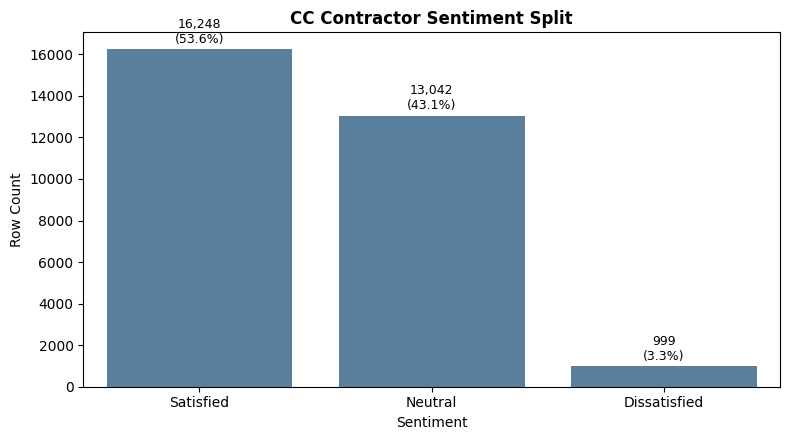

In [19]:
# Sentiment Analysis (core signal) - Part 1: categorical split
sentiment_order = ['Satisfied', 'Neutral', 'Dissatisfied']
sentiment_series = df['cc_contractor_sentiment'].astype(str).str.strip()
sentiment_counts = sentiment_series.value_counts().reindex(sentiment_order, fill_value=0)
sentiment_pct = (sentiment_counts / sentiment_counts.sum() * 100).round(1)

print('=== OVERALL SENTIMENT SPLIT ===')
for label in sentiment_order:
    print(f"{label}: {sentiment_counts[label]:,} ({sentiment_pct[label]:.1f}%)")

# Visualisation 1: categorical sentiment split
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, color='#4f81a8')
ax.set_title('CC Contractor Sentiment Split', fontsize=12, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Row Count')
for i, v in enumerate(sentiment_counts.values):
    ax.text(i, v + sentiment_counts.max() * 0.01, f"{v:,}\n({sentiment_pct.iloc[i]:.1f}%)", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Converted score dtypes:
cc_contractor_sentiment_start_score      float64
cc_contractor_sentiment_end_score        float64
cc_contractor_sentiment_overall_score    float64


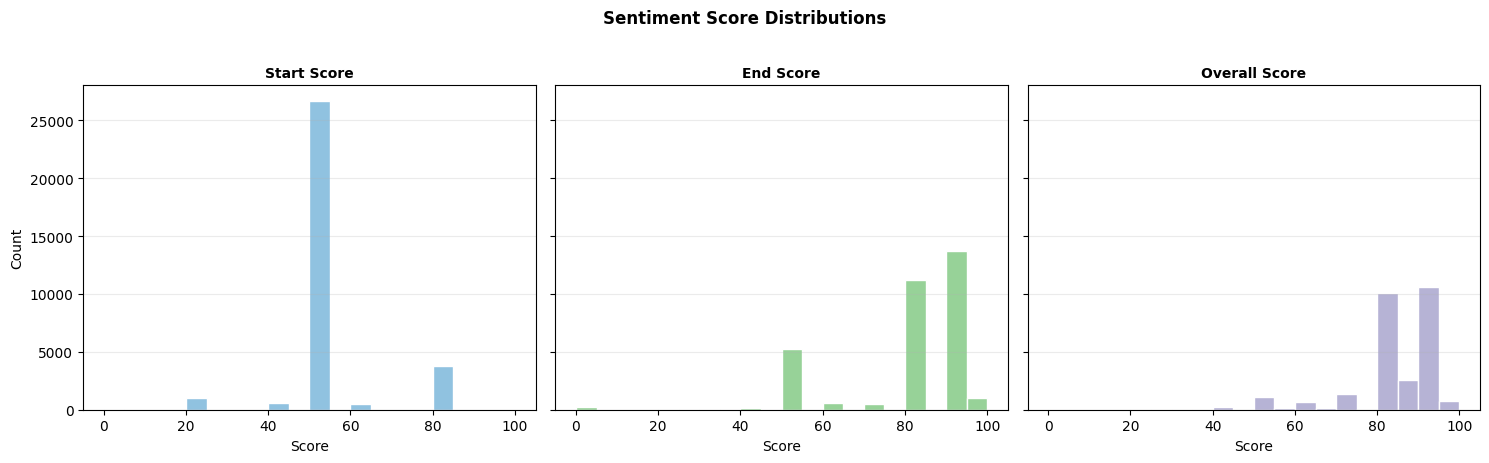

In [20]:
# Sentiment Analysis (core signal) - Part 2: numeric score conversion + histograms
score_cols = [
    'cc_contractor_sentiment_start_score',
    'cc_contractor_sentiment_end_score',
    'cc_contractor_sentiment_overall_score',
]
for col in score_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Converted score dtypes:')
print(df[score_cols].dtypes.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
hist_colors = ['#6baed6', '#74c476', '#9e9ac8']
for i, col in enumerate(score_cols):
    sns.histplot(df[col].dropna(), bins=20, ax=axes[i], color=hist_colors[i], edgecolor='white')
    axes[i].set_title(col.replace('cc_contractor_sentiment_', '').replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y', alpha=0.25)
plt.suptitle('Sentiment Score Distributions', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

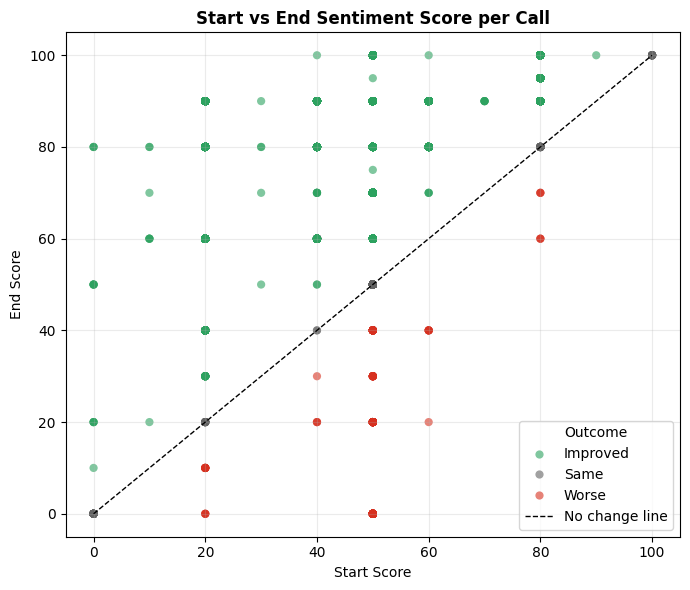

=== SENTIMENT CHANGE SIGNAL ===
Calls with scored start & end: 32,593
Improved (end > start): 27,008
No change (end = start): 5,338
Worsened (end < start): 247 (0.8%)
Critical churn signal: calls where end score < start score indicate sentiment worsened during support interaction.


In [21]:
# Sentiment Analysis (core signal) - Part 3: start vs end scatter (key chart)
score_df = df[['cc_contractor_sentiment_start_score', 'cc_contractor_sentiment_end_score']].dropna().copy()
score_df['delta'] = score_df['cc_contractor_sentiment_end_score'] - score_df['cc_contractor_sentiment_start_score']

worse_mask = score_df['delta'] < 0
improve_mask = score_df['delta'] > 0
same_mask = score_df['delta'] == 0

total_scored_calls = score_df.shape[0]
worse_calls = int(worse_mask.sum())
improved_calls = int(improve_mask.sum())
same_calls = int(same_mask.sum())
worse_pct = (worse_calls / total_scored_calls) * 100 if total_scored_calls else 0

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=score_df,
    x='cc_contractor_sentiment_start_score',
    y='cc_contractor_sentiment_end_score',
    hue=np.where(worse_mask, 'Worse', np.where(improve_mask, 'Improved', 'Same')),
    palette={'Worse': '#d7301f', 'Improved': '#2ca25f', 'Same': '#636363'},
    alpha=0.6,
    s=35,
    linewidth=0
)
min_score = min(score_df['cc_contractor_sentiment_start_score'].min(), score_df['cc_contractor_sentiment_end_score'].min())
max_score = max(score_df['cc_contractor_sentiment_start_score'].max(), score_df['cc_contractor_sentiment_end_score'].max())
plt.plot([min_score, max_score], [min_score, max_score], '--', color='black', linewidth=1, label='No change line')
plt.title('Start vs End Sentiment Score per Call', fontsize=12, fontweight='bold')
plt.xlabel('Start Score')
plt.ylabel('End Score')
plt.grid(alpha=0.25)
plt.legend(title='Outcome', loc='best')
plt.tight_layout()
plt.show()

print('=== SENTIMENT CHANGE SIGNAL ===')
print(f"Calls with scored start & end: {total_scored_calls:,}")
print(f"Improved (end > start): {improved_calls:,}")
print(f"No change (end = start): {same_calls:,}")
print(f"Worsened (end < start): {worse_calls:,} ({worse_pct:.1f}%)")
print('Critical churn signal: calls where end score < start score indicate sentiment worsened during support interaction.')

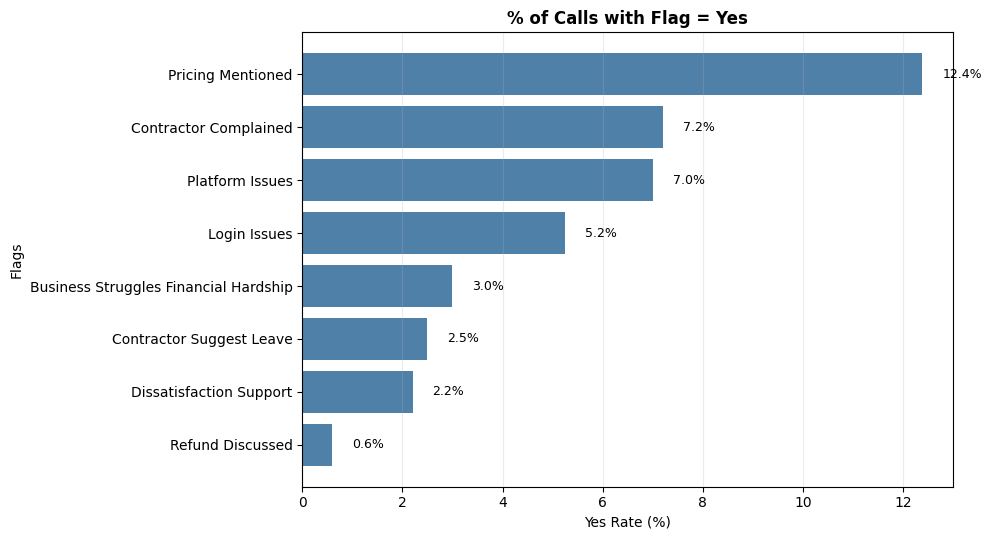

In [22]:
# Issue/Behavior Flags: % of calls where flag == Yes (visualization)
flag_cols = [
    'cc_contractor_suggest_leave',
    'cc_contractor_complained',
    'cc_business_struggles_financial_hardship',
    'cc_platform_issues',
    'cc_login_issues',
    'cc_pricing_mentioned',
    'cc_refund_discussed',
    'cc_dissatisfaction_support',
]

yes_pct = (
    df[flag_cols]
    .apply(lambda s: s.astype(str).str.strip().str.lower().eq('yes').mean() * 100)
    .sort_values(ascending=True)
)

plot_labels = [c.replace('cc_', '').replace('_', ' ').title() for c in yes_pct.index]

plt.figure(figsize=(10, 5.5))
ax = plt.barh(plot_labels, yes_pct.values, color='#4f81a8')
plt.title('% of Calls with Flag = Yes', fontsize=12, fontweight='bold')
plt.xlabel('Yes Rate (%)')
plt.ylabel('Flags')
plt.grid(axis='x', alpha=0.25)

for i, val in enumerate(yes_pct.values):
    plt.text(val + 0.4, i, f"{val:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
# Issue/Behavior Flags: question answers
total_calls = len(df)

leave_yes = df['cc_contractor_suggest_leave'].astype(str).str.strip().str.lower().eq('yes').sum()
leave_pct = (leave_yes / total_calls) * 100

platform_yes = df['cc_platform_issues'].astype(str).str.strip().str.lower().eq('yes').sum()
login_yes = df['cc_login_issues'].astype(str).str.strip().str.lower().eq('yes').sum()
pricing_yes = df['cc_pricing_mentioned'].astype(str).str.strip().str.lower().eq('yes').sum()

platform_pct = (platform_yes / total_calls) * 100
login_pct = (login_yes / total_calls) * 100
pricing_pct = (pricing_yes / total_calls) * 100
platform_login_yes = platform_yes + login_yes
platform_login_pct = platform_pct + login_pct

print('=== KEY QUESTIONS ===')
print(f"Calls with customer suggesting/threatening to leave: {leave_yes:,} ({leave_pct:.1f}% of calls)")

print('\nPlatform/Login issues vs Pricing complaints:')
print(f"- Platform issues: {platform_yes:,} ({platform_pct:.1f}%)")
print(f"- Login issues: {login_yes:,} ({login_pct:.1f}%)")
print(f"- Combined platform+login signal: {platform_login_yes:,} ({platform_login_pct:.1f}%)")
print(f"- Pricing mentioned: {pricing_yes:,} ({pricing_pct:.1f}%)")

if platform_login_pct > pricing_pct:
    print('Finding: Platform/login issues are more common than pricing complaints.')
elif platform_login_pct < pricing_pct:
    print('Finding: Pricing complaints are more common than platform/login issues.')
else:
    print('Finding: Platform/login issues and pricing complaints are equally common.')

=== KEY QUESTIONS ===
Calls with customer suggesting/threatening to leave: 820 (2.5% of calls)

Platform/Login issues vs Pricing complaints:
- Platform issues: 2,303 (7.0%)
- Login issues: 1,724 (5.2%)
- Combined platform+login signal: 4,027 (12.2%)
- Pricing mentioned: 4,073 (12.4%)
Finding: Pricing complaints are more common than platform/login issues.


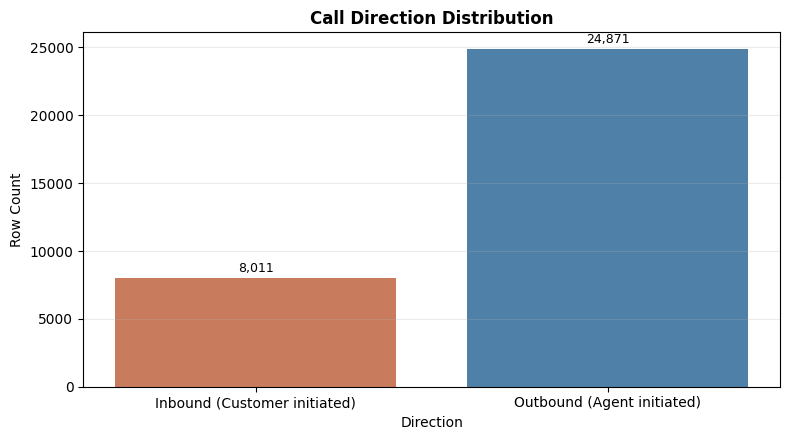

=== DIRECTION SUMMARY ===
Inbound calls: 8,011 (24.4%)
Outbound calls: 24,871 (75.6%)
Interpretation: This tells us whether customers are mostly reaching out or agents are proactively calling.


In [24]:
# Direction analysis: who initiates the call?
direction_counts = df['Direction'].astype(str).str.strip().str.upper().value_counts()
direction_counts = direction_counts.reindex(['IN_BOUND', 'OUT_BOUND'], fill_value=0)
direction_labels = ['Inbound (Customer initiated)', 'Outbound (Agent initiated)']

plt.figure(figsize=(8, 4.5))
bars = plt.bar(direction_labels, direction_counts.values, color=['#c97c5d', '#4f81a8'])
plt.title('Call Direction Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Direction')
plt.ylabel('Row Count')
plt.grid(axis='y', alpha=0.25)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + direction_counts.max() * 0.01, f"{int(h):,}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

total_calls = int(direction_counts.sum())
inbound_pct = (direction_counts.loc['IN_BOUND'] / total_calls) * 100 if total_calls else 0
outbound_pct = (direction_counts.loc['OUT_BOUND'] / total_calls) * 100 if total_calls else 0

print('=== DIRECTION SUMMARY ===')
print(f"Inbound calls: {direction_counts.loc['IN_BOUND']:,} ({inbound_pct:.1f}%)")
print(f"Outbound calls: {direction_counts.loc['OUT_BOUND']:,} ({outbound_pct:.1f}%)")
print('Interpretation: This tells us whether customers are mostly reaching out or agents are proactively calling.')

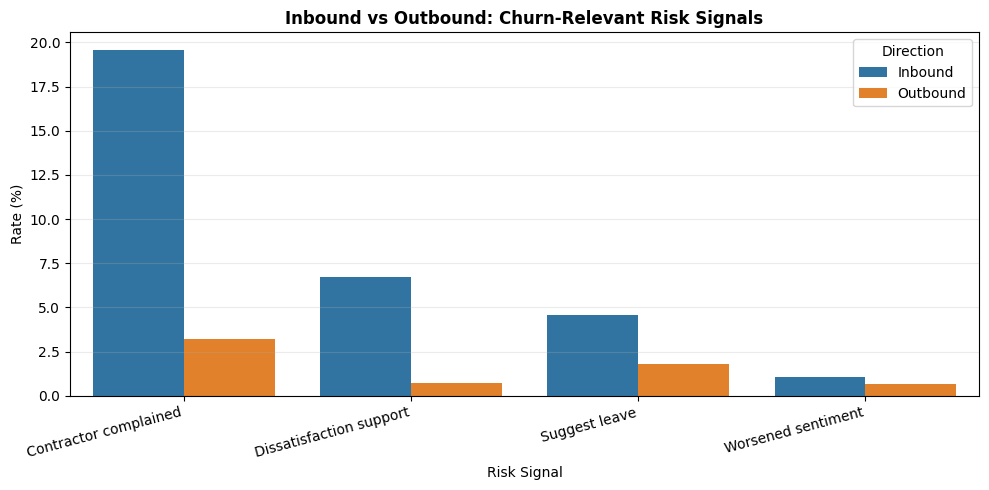

=== CHURN-RELEVANT DIRECTION COMPARISON (PROXY) ===
                 complaint_rate  dissatisfaction_rate  suggest_leave_rate  worsened_sentiment_rate
Direction_clean                                                                                   
IN_BOUND                  19.59                  6.72                4.56                     1.07
OUT_BOUND                  3.20                  0.75                1.83                     0.65

Finding: Inbound calls show higher complaint intensity than outbound calls, suggesting stronger churn risk signal in inbound complaints.
Note: This is a churn-relevant proxy comparison. True predictiveness requires joining to renewal/churn outcomes.


In [25]:
# Churn-relevant comparison by direction (proxy risk signals)
dir_df = df.copy()
dir_df['Direction_clean'] = dir_df['Direction'].astype(str).str.strip().str.upper()
dir_df = dir_df[dir_df['Direction_clean'].isin(['IN_BOUND', 'OUT_BOUND'])].copy()

# Complaint/negative flags by direction
dir_df['complained_yes'] = dir_df['cc_contractor_complained'].astype(str).str.strip().str.lower().eq('yes')
dir_df['dissatisfaction_yes'] = dir_df['cc_dissatisfaction_support'].astype(str).str.strip().str.lower().eq('yes')
dir_df['suggest_leave_yes'] = dir_df['cc_contractor_suggest_leave'].astype(str).str.strip().str.lower().eq('yes')

# Worsened sentiment by direction (if score columns exist as numeric from prior cells)
if 'cc_contractor_sentiment_start_score' in dir_df.columns and 'cc_contractor_sentiment_end_score' in dir_df.columns:
    start_num = pd.to_numeric(dir_df['cc_contractor_sentiment_start_score'], errors='coerce')
    end_num = pd.to_numeric(dir_df['cc_contractor_sentiment_end_score'], errors='coerce')
    dir_df['worsened_sentiment'] = end_num < start_num
else:
    dir_df['worsened_sentiment'] = False

risk_by_direction = (
    dir_df.groupby('Direction_clean')
    .agg(
        call_count=('Direction_clean', 'size'),
        complaint_rate=('complained_yes', 'mean'),
        dissatisfaction_rate=('dissatisfaction_yes', 'mean'),
        suggest_leave_rate=('suggest_leave_yes', 'mean'),
        worsened_sentiment_rate=('worsened_sentiment', 'mean')
    )
    .reindex(['IN_BOUND', 'OUT_BOUND'])
)

risk_by_direction_pct = risk_by_direction[['complaint_rate', 'dissatisfaction_rate', 'suggest_leave_rate', 'worsened_sentiment_rate']] * 100
risk_plot = risk_by_direction_pct.reset_index().melt(id_vars='Direction_clean', var_name='metric', value_name='pct')
risk_plot['Direction'] = risk_plot['Direction_clean'].map({'IN_BOUND': 'Inbound', 'OUT_BOUND': 'Outbound'})
risk_plot['Metric'] = risk_plot['metric'].map({
    'complaint_rate': 'Contractor complained',
    'dissatisfaction_rate': 'Dissatisfaction support',
    'suggest_leave_rate': 'Suggest leave',
    'worsened_sentiment_rate': 'Worsened sentiment',
})

plt.figure(figsize=(10, 5))
sns.barplot(data=risk_plot, x='Metric', y='pct', hue='Direction')
plt.title('Inbound vs Outbound: Churn-Relevant Risk Signals', fontsize=12, fontweight='bold')
plt.xlabel('Risk Signal')
plt.ylabel('Rate (%)')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.25)
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

print('=== CHURN-RELEVANT DIRECTION COMPARISON (PROXY) ===')
print((risk_by_direction_pct.round(2)).to_string())

in_complaint = risk_by_direction_pct.loc['IN_BOUND', 'complaint_rate']
out_complaint = risk_by_direction_pct.loc['OUT_BOUND', 'complaint_rate']
if in_complaint > out_complaint:
    print('\nFinding: Inbound calls show higher complaint intensity than outbound calls, suggesting stronger churn risk signal in inbound complaints.')
elif in_complaint < out_complaint:
    print('\nFinding: Outbound calls show higher complaint intensity than inbound calls in this dataset.')
else:
    print('\nFinding: Inbound and outbound complaint intensity are similar in this dataset.')

print('Note: This is a churn-relevant proxy comparison. True predictiveness requires joining to renewal/churn outcomes.')

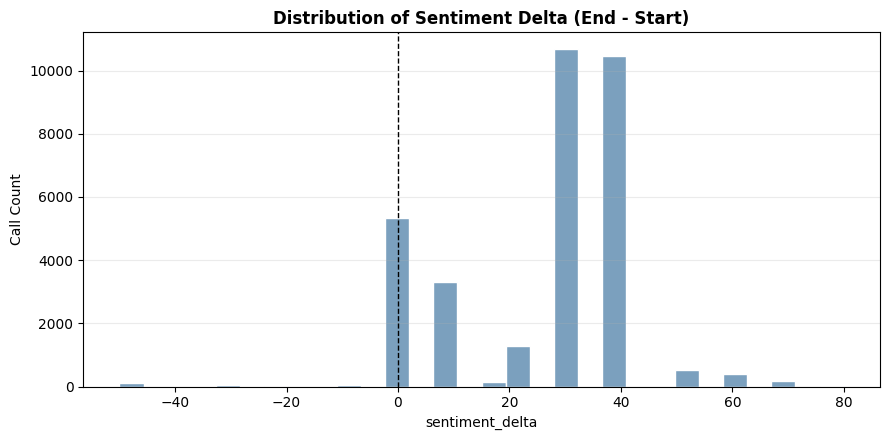

=== SENTIMENT DELTA SUMMARY ===
Calls with valid delta: 32,593
Positive delta (agent recovered customer): 82.9%
Negative delta (call made things worse): 0.8%
Zero delta (no change): 16.4%


In [26]:
# Sentiment delta: derive column and histogram
df['start_score_num'] = pd.to_numeric(df['cc_contractor_sentiment_start_score'], errors='coerce')
df['end_score_num'] = pd.to_numeric(df['cc_contractor_sentiment_end_score'], errors='coerce')
df['sentiment_delta'] = df['end_score_num'] - df['start_score_num']

delta_series = df['sentiment_delta'].dropna()

plt.figure(figsize=(9, 4.5))
sns.histplot(delta_series, bins=30, color='#4f81a8', edgecolor='white')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Distribution of Sentiment Delta (End - Start)', fontsize=12, fontweight='bold')
plt.xlabel('sentiment_delta')
plt.ylabel('Call Count')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

improved_share = (delta_series > 0).mean() * 100
worse_share = (delta_series < 0).mean() * 100
flat_share = (delta_series == 0).mean() * 100

print('=== SENTIMENT DELTA SUMMARY ===')
print(f"Calls with valid delta: {len(delta_series):,}")
print(f"Positive delta (agent recovered customer): {improved_share:.1f}%")
print(f"Negative delta (call made things worse): {worse_share:.1f}%")
print(f"Zero delta (no change): {flat_share:.1f}%")

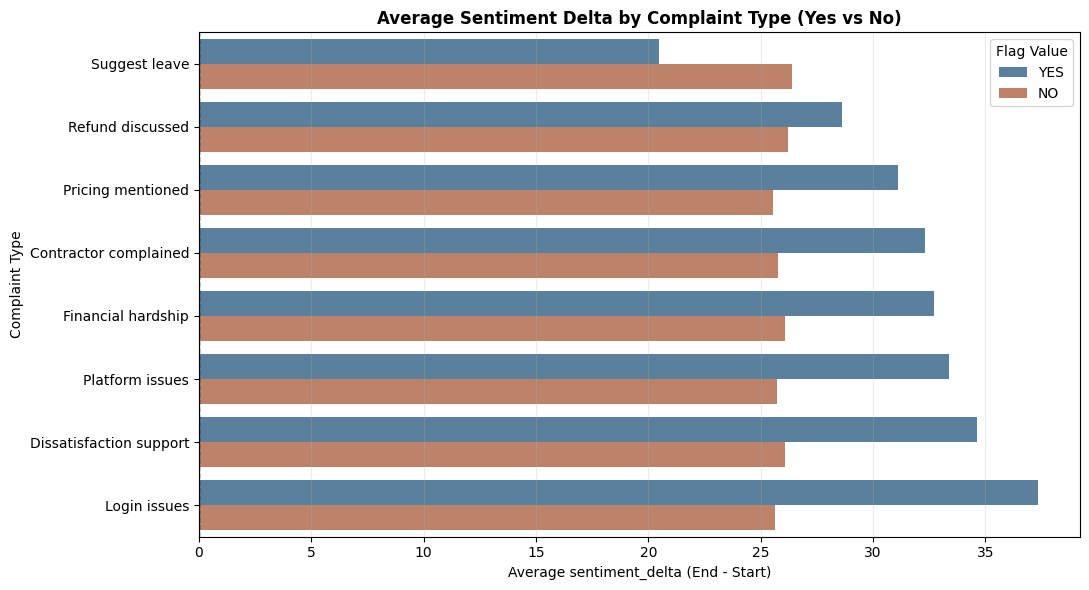

=== AVERAGE DELTA BY COMPLAINT TYPE (YES vs NO) ===
                        Avg Delta           Calls        
Flag Value                     NO    YES       NO     YES
Complaint Type                                           
Suggest leave               26.38  20.48  31756.0   819.0
Refund discussed            26.22  28.63  32396.0   197.0
Pricing mentioned           25.54  31.10  28520.0  4073.0
Contractor complained       25.76  32.31  30211.0  2365.0
Financial hardship          26.10  32.71  31455.0   977.0
Platform issues             25.72  33.37  30260.0  2290.0
Dissatisfaction support     26.07  34.62  31830.0   717.0
Login issues                25.64  37.35  30827.0  1715.0

=== TYPES THAT END WORSE THAN THEY STARTED ===
No complaint types have negative average delta for either YES or NO groups.


In [28]:
# Average sentiment delta by complaint type (Yes and No)
complaint_flags = {
    'Contractor complained': 'cc_contractor_complained',
    'Dissatisfaction support': 'cc_dissatisfaction_support',
    'Suggest leave': 'cc_contractor_suggest_leave',
    'Platform issues': 'cc_platform_issues',
    'Login issues': 'cc_login_issues',
    'Pricing mentioned': 'cc_pricing_mentioned',
    'Refund discussed': 'cc_refund_discussed',
    'Financial hardship': 'cc_business_struggles_financial_hardship',
}

rows = []
for label, col in complaint_flags.items():
    status = df[col].astype(str).str.strip().str.lower()
    for yn in ['yes', 'no']:
        mask = status.eq(yn) & df['sentiment_delta'].notna()
        subset = df.loc[mask, 'sentiment_delta']
        rows.append({
            'Complaint Type': label,
            'Flag Value': yn.upper(),
            'Avg Delta': subset.mean() if len(subset) > 0 else np.nan,
            'Calls': len(subset)
        })

delta_by_type = pd.DataFrame(rows).dropna()

# Order complaint types by average delta for YES group
order_yes = (
    delta_by_type[delta_by_type['Flag Value'] == 'YES']
    .sort_values('Avg Delta', ascending=True)['Complaint Type']
    .tolist()
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=delta_by_type,
    y='Complaint Type',
    x='Avg Delta',
    hue='Flag Value',
    order=order_yes,
    palette={'YES': '#4f81a8', 'NO': '#c97c5d'}
)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Average Sentiment Delta by Complaint Type (Yes vs No)', fontsize=12, fontweight='bold')
plt.xlabel('Average sentiment_delta (End - Start)')
plt.ylabel('Complaint Type')
plt.grid(axis='x', alpha=0.25)
plt.legend(title='Flag Value')
plt.tight_layout()
plt.show()

summary_table = (
    delta_by_type.pivot_table(
        index='Complaint Type',
        columns='Flag Value',
        values=['Avg Delta', 'Calls']
    )
    .sort_values(('Avg Delta', 'YES'))
)

print('=== AVERAGE DELTA BY COMPLAINT TYPE (YES vs NO) ===')
print(summary_table.round(2).to_string())

ending_worse_yes = delta_by_type[(delta_by_type['Flag Value'] == 'YES') & (delta_by_type['Avg Delta'] < 0)]
ending_worse_no = delta_by_type[(delta_by_type['Flag Value'] == 'NO') & (delta_by_type['Avg Delta'] < 0)]

print('\n=== TYPES THAT END WORSE THAN THEY STARTED ===')
if ending_worse_yes.empty and ending_worse_no.empty:
    print('No complaint types have negative average delta for either YES or NO groups.')
else:
    if not ending_worse_yes.empty:
        print('\nYES group negative averages:')
        print(ending_worse_yes[['Complaint Type', 'Avg Delta', 'Calls']].to_string(index=False))
    if not ending_worse_no.empty:
        print('\nNO group negative averages:')
        print(ending_worse_no[['Complaint Type', 'Avg Delta', 'Calls']].to_string(index=False))

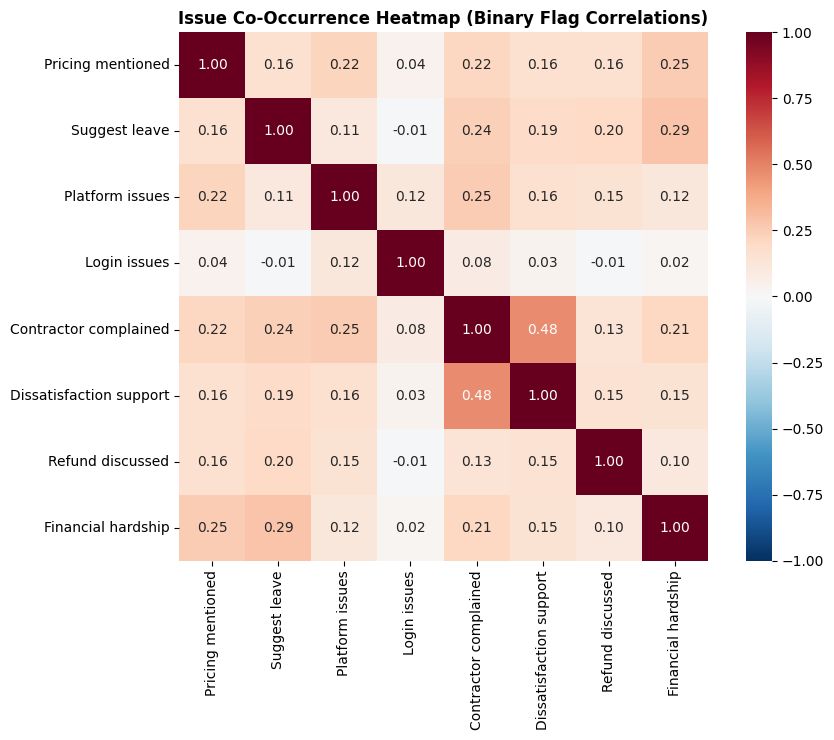

=== TARGETED QUESTIONS ===
When cc_pricing_mentioned = Yes, does cc_contractor_suggest_leave = Yes more often?
- P(suggest_leave=Yes | pricing=Yes): 9.13%
- P(suggest_leave=Yes | pricing=No):  1.56%
- Uplift (Yes - No): 7.58 pp

When cc_platform_issues = Yes, what happens to sentiment?
- Avg sentiment_delta when platform=Yes: 33.37
- Avg sentiment_delta when platform=No:  25.70
- Negative-delta rate when platform=Yes: 2.14%
- Negative-delta rate when platform=No:  0.65%

Clustering note: stronger positive cells in the heatmap indicate issues that tend to co-occur in the same call.


In [29]:
# Problem clustering heatmap + targeted checks
cluster_flags = [
    'cc_pricing_mentioned',
    'cc_contractor_suggest_leave',
    'cc_platform_issues',
    'cc_login_issues',
    'cc_contractor_complained',
    'cc_dissatisfaction_support',
    'cc_refund_discussed',
    'cc_business_struggles_financial_hardship',
]

flag_bin = df[cluster_flags].apply(
    lambda s: s.astype(str).str.strip().str.lower().eq('yes').astype(int)
)

# Heatmap of co-occurrence tendency (phi-style correlation for binary flags)
corr = flag_bin.corr()
rename_map = {
    'cc_pricing_mentioned': 'Pricing mentioned',
    'cc_contractor_suggest_leave': 'Suggest leave',
    'cc_platform_issues': 'Platform issues',
    'cc_login_issues': 'Login issues',
    'cc_contractor_complained': 'Contractor complained',
    'cc_dissatisfaction_support': 'Dissatisfaction support',
    'cc_refund_discussed': 'Refund discussed',
    'cc_business_struggles_financial_hardship': 'Financial hardship',
}
corr = corr.rename(index=rename_map, columns=rename_map)

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Issue Co-Occurrence Heatmap (Binary Flag Correlations)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Q1: When pricing is mentioned, does suggest_leave happen more often?
pricing_yes = flag_bin['cc_pricing_mentioned'] == 1
suggest_leave_yes = flag_bin['cc_contractor_suggest_leave'] == 1
p_leave_given_pricing_yes = suggest_leave_yes[pricing_yes].mean() * 100
p_leave_given_pricing_no = suggest_leave_yes[~pricing_yes].mean() * 100
uplift_leave = p_leave_given_pricing_yes - p_leave_given_pricing_no

# Q2: When platform issues are Yes, what happens to sentiment?
platform_yes = flag_bin['cc_platform_issues'] == 1
valid_delta = df['sentiment_delta'].notna()

avg_delta_platform_yes = df.loc[platform_yes & valid_delta, 'sentiment_delta'].mean()
avg_delta_platform_no = df.loc[~platform_yes & valid_delta, 'sentiment_delta'].mean()
neg_delta_rate_platform_yes = (df.loc[platform_yes & valid_delta, 'sentiment_delta'] < 0).mean() * 100
neg_delta_rate_platform_no = (df.loc[~platform_yes & valid_delta, 'sentiment_delta'] < 0).mean() * 100

print('=== TARGETED QUESTIONS ===')
print('When cc_pricing_mentioned = Yes, does cc_contractor_suggest_leave = Yes more often?')
print(f"- P(suggest_leave=Yes | pricing=Yes): {p_leave_given_pricing_yes:.2f}%")
print(f"- P(suggest_leave=Yes | pricing=No):  {p_leave_given_pricing_no:.2f}%")
print(f"- Uplift (Yes - No): {uplift_leave:.2f} pp")

print('\nWhen cc_platform_issues = Yes, what happens to sentiment?')
print(f"- Avg sentiment_delta when platform=Yes: {avg_delta_platform_yes:.2f}")
print(f"- Avg sentiment_delta when platform=No:  {avg_delta_platform_no:.2f}")
print(f"- Negative-delta rate when platform=Yes: {neg_delta_rate_platform_yes:.2f}%")
print(f"- Negative-delta rate when platform=No:  {neg_delta_rate_platform_no:.2f}%")

print('\nClustering note: stronger positive cells in the heatmap indicate issues that tend to co-occur in the same call.')

## Key Findings Summary

### Sentiment Columns Needing Cleaning
These fields arrived as object-like text and should be validated/cleaned at ingest:
- `cc_contractor_sentiment_start_score`
- `cc_contractor_sentiment_end_score`
- `cc_contractor_sentiment_overall_score`
Current notebook converts them with `pd.to_numeric(..., errors='coerce')`.

### 2024 Sparse Coverage Note
- The file starts in **2024** (no 2023 rows in this extract).
- 2024 rows are **5,431** out of 32,882 total rows (**16.5% row share**).
- Treat 2024 analyses as relatively sparse vs 2025 coverage.

### Average Sentiment Delta: Helping or Hurting?
- `sentiment_delta = end_score - start_score`
- Average `sentiment_delta` is **+26.24**.
- Overall, support calls are helping more often than hurting.
- Distribution check: **82.9% positive**, **0.8% negative**, **16.4% unchanged**.

### Most Common Complaint Types
Top complaint/issue flags by `% Yes` in calls:
- **Pricing mentioned:** 12.4%
- **Contractor complained:** 7.2%
- **Platform issues:** 7.0%
- **Login issues:** 5.2%
- **Financial hardship:** 3.0%

### Customer Support Reach
- **31.3%** of billing customers ever called support (**14,988 / 47,826**).
- Most customers did **not** call support (useful stability signal).